<a href="https://colab.research.google.com/github/javmencia/RBLog/blob/main/HIVEpcSurvival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Step 0: Setting up environment...")

# Manual 3D array creation function
def create_3d_array(matrix_list):
    if len(matrix_list) == 0:
        raise ValueError("No matrices provided")

    # Get dimensions from first matrix
    n_samples = len(matrix_list)
    n_timesteps = matrix_list[0].shape[0]
    n_features = matrix_list[0].shape[1]

    # Create empty 3D array
    array_3d = np.zeros((n_samples, n_timesteps, n_features))

    # Fill array
    for i in range(n_samples):
        array_3d[i, :, :] = matrix_list[i]

    return array_3d

print("Environment setup complete!")

# Load the data
print("Loading pcdata.csv...")
try:
    sequential_data = pd.read_csv('pcdata.csv')
    print(f"Data loaded successfully! Shape: {sequential_data.shape}")
    print(f"Columns: {sequential_data.columns.tolist()}")
except FileNotFoundError:
    print("ERROR: pcdata.csv file not found. Please ensure the file is in your working directory.")
    exit()


Step 0: Setting up environment...
Environment setup complete!
Loading pcdata.csv...
Data loaded successfully! Shape: (8121, 101)
Columns: ['Unnamed: 0', 'RPT', 'RINVSITE', 'STUDY', 'SEXN', 'SEX', 'RACEPRIM', 'INFCDAY', 'AGE', 'VISIT', 'VISNAME', 'DOV_ND', 'VISDAY', 'ECOGGRN', 'ECOGGR', 'STATUSN', 'STATUS', 'CONTDAY', 'LKDAY', 'DSCAUSEN', 'DSCAUSE', 'DSREAS', 'DSDECOD', 'DSBODSYS', 'DSMODIFY', 'LLTCD', 'LLTNMD', 'HLTNMD', 'HLGTNMD', 'PTCDD', 'DICTVER', 'DSDAY', 'HEIGHT', 'HEIGHTU', 'WEIGHT', 'WEIGHTU', 'BMI', 'TEMP', 'TEMPU', 'SYSBP', 'DIABP', 'DIABPU', 'PULSE', 'PULSEU', 'VTDAY', 'EXDOSENN', 'EXDOSEN', 'EXDOSE2N', 'EXDOSE2', 'EXDOSE3N', 'EXDOSE3', 'REGION', 'ENROLLDAY', 'PKSAMPN', 'PKSAMP', 'TYPEPKN', 'TYPEPK', 'PKDAY', 'TARGETQN', 'TARGETQ', 'NONTARQN', 'NONTARQ', 'cycle_number', 'total_cycles', 'anytarget', 'anynontarget', 'os_event', 'CANCDEAD', 'visit_sequence', 'total_ae_events', 'serious_ae_count', 'grade3_plus_count', 'any_grade3_plus', 'total_body_systems', 'body_systems_list',


Step 1: Preparing LSTM data...
Available features: ['ECOGGRN', 'total_ae_events', 'serious_ae_count', 'grade3_plus_count', 'AGE', 'VISIT', 'EXDOSENN', 'EXDOSE2N', 'EXDOSE3N', 'PKSAMPN', 'TYPEPKN', 'TARGETQN', 'NONTARQN', 'total_ae_events', 'serious_ae_count', 'grade3_plus_count', 'total_body_systems', 'treatment_related_count', 'other_treatment_related_count', 'any_treatment_related', 'drug_interrupted', 'drug_reduced', 'drug_withdrawn', 'drug_not_changed', 'other_drug_interrupted', 'other_drug_reduced', 'other_drug_withdrawn', 'concomitant_treatment_given', 'grade1_count', 'grade2_count', 'grade3_count', 'grade4_count', 'grade5_count', 'ongoing_ae_count', 'mean_ae_duration', 'max_ae_duration', 'most_recent_ae_term', 'most_recent_ae_severity', 'cum_any_grade3_plus', 'cum_any_treatment_related', 'cum_drug_withdrawn', 'cum_other_drug_withdrawn', 'cum_concomitant_treatment']
ERROR in data preparation: Columns must be same length as key

DIAGNOSTIC INFORMATION:
Number of patients: 526
Var

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,665 (22.13 KB)

 Trainable params: 5,665 (22.13 KB)

 Non-trainable params: 0 (0.00 B)


Step 5: Training LSTM model...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - AUC: 0.4808 - accuracy: 0.0893 - loss: 0.6970 - val_AUC: 0.4375 - val_accuracy: 0.0541 - val_loss: 0.5388
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - AUC: 0.5049 - accuracy: 0.1313 - loss: 0.5028 - val_AUC: 0.4461 - val_accuracy: 0.0811 - val_loss: 0.3631
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.4612 - accuracy: 0.1524 - loss: 0.3546 - val_AUC: 0.4571 - val_accuracy: 0.0811 - val_loss: 0.1862
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - AUC: 0.4037 - accuracy: 0.1665 - loss: 0.1767 - val_AUC: 0.4816 - val_accuracy: 0.0811 - val_loss: -0.0104
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.4729 - accuracy: 0.1661 - loss: -0.0227 - val_AUC: 0.4877 - val_accuracy: 0.0811 - val_loss: -0.2368
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.4551 - accuracy: 0.1429 - loss: -0.2353 - val_AUC: 0.4963 - val_accuracy: 0.0811 - val_loss: -0.5202
Epoch 7/5

ValueError: y_true takes value in {-1, 0} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

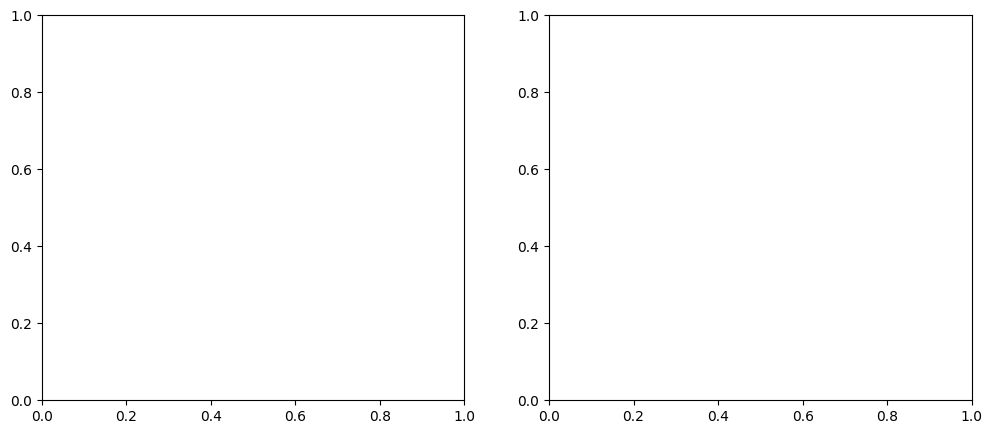

In [3]:

print("\nStep 1: Preparing LSTM data...")

def prepare_lstm_manual(data, sequence_length=3):
    # Select features that are likely to be numeric
    feature_cols = ['ECOGGRN', 'total_ae_events', 'serious_ae_count',
                   'grade3_plus_count', 'AGE', 'VISIT', 'EXDOSENN', 'EXDOSE2N', 'EXDOSE3N', 'PKSAMPN', 'TYPEPKN', 'TARGETQN', 'NONTARQN', 'total_ae_events', 'serious_ae_count', 'grade3_plus_count', 'total_body_systems', 'treatment_related_count', 'other_treatment_related_count', 'any_treatment_related', 'drug_interrupted', 'drug_reduced', 'drug_withdrawn', 'drug_not_changed', 'other_drug_interrupted', 'other_drug_reduced', 'other_drug_withdrawn', 'concomitant_treatment_given', 'grade1_count', 'grade2_count', 'grade3_count', 'grade4_count', 'grade5_count', 'ongoing_ae_count', 'mean_ae_duration', 'max_ae_duration', 'most_recent_ae_term', 'most_recent_ae_severity', 'cum_any_grade3_plus', 'cum_any_treatment_related', 'cum_drug_withdrawn', 'cum_other_drug_withdrawn', 'cum_concomitant_treatment']

    # Check which feature columns exist in the data
    available_features = [col for col in feature_cols if col in data.columns]
    print(f"Available features: {available_features}")

    # Prepare data
    data_prep = data.copy()

    # Create outcome variable (assuming CANCDEAD exists)
    if 'CANCDEAD' in data_prep.columns:
        data_prep['outcome'] = data_prep['CANCDEAD'].astype(int) - 1
    else:
        print("WARNING: CANCDEAD column not found. Creating dummy outcome.")
        data_prep['outcome'] = 0

    # Group by patient and count visits
    visit_counts = data_prep.groupby('RPT').size()
    valid_patients = visit_counts[visit_counts >= sequence_length].index

    data_prep = data_prep[data_prep['RPT'].isin(valid_patients)]

    # Convert features to numeric and fill NaN
    for col in available_features:
        data_prep[col] = pd.to_numeric(data_prep[col], errors='coerce')

    data_prep[available_features] = data_prep[available_features].fillna(0)

    patients = data_prep['RPT'].unique()
    sequences = []
    labels = []

    print(f"Processing {len(patients)} patients with sufficient visits...")

    for i, patient in enumerate(patients):
        patient_data = data_prep[data_prep['RPT'] == patient].sort_values('VISDAY')

        if len(patient_data) >= sequence_length:
            # Get the outcome (assuming it's constant per patient)
            patient_outcome = patient_data['outcome'].iloc[0]

            # Extract features as matrix
            feature_matrix = patient_data[available_features].values

            # Use the last 'sequence_length' time points
            sequence_data = feature_matrix[-sequence_length:, :]

            sequences.append(sequence_data)
            labels.append(patient_outcome)

        # Progress indicator
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1} patients...")

    print(f"Created {len(sequences)} sequences total")

    if len(sequences) == 0:
        raise ValueError("No sequences were created. Possible issues:\n"
                        f"- Not enough patients with {sequence_length} visits\n"
                        "- Feature columns may contain non-numeric data\n"
                        "- Check if CANCDEAD variable exists and has values")

    # Create 3D array using our manual function
    sequences_array = create_3d_array(sequences)

    return {
        'sequences': sequences_array,
        'labels': np.array(labels)
    }

# Prepare the data
try:
    lstm_data = prepare_lstm_manual(sequential_data, sequence_length=3)
    print("SUCCESS: LSTM data prepared!")
    print(f"Sequences dimension: {lstm_data['sequences'].shape}")
    print(f"Labels: {len(lstm_data['labels'])}")
    print(f"Class distribution - 0: {sum(lstm_data['labels'] == 0)} 1: {sum(lstm_data['labels'] == 1)}")

except Exception as e:
    print(f"ERROR in data preparation: {e}")

    # Diagnostic information
    print("\nDIAGNOSTIC INFORMATION:")
    print(f"Number of patients: {sequential_data['RPT'].nunique()}")
    print(f"Variables in sequential_data: {sequential_data.columns.tolist()}")
    if 'CANCDEAD' in sequential_data.columns:
        print(f"CANCDEAD values:\n{sequential_data['CANCDEAD'].value_counts()}")

    visit_counts = sequential_data.groupby('RPT').size()
    print("Visit counts summary:")
    print(visit_counts.describe())

print("\nStep 2: Normalizing data...")

def normalize_3d_manual(array_3d):
    dims = array_3d.shape
    print(f"Normalizing array with dimensions: {dims}")

    # Normalize each feature across all samples and timesteps
    for feature_idx in range(dims[2]):
        feature_data = array_3d[:, :, feature_idx]
        mean_val = np.mean(feature_data)
        sd_val = np.std(feature_data)

        if sd_val > 0:
            array_3d[:, :, feature_idx] = (feature_data - mean_val) / sd_val
        # If sd = 0, leave as is (constant feature)

    array_3d = np.nan_to_num(array_3d)
    return array_3d

if 'lstm_data' in locals():
    X_sequences = normalize_3d_manual(lstm_data['sequences'].copy())
    y = lstm_data['labels']

    print("Normalization completed!")
    print(f"Data range: [{X_sequences.min():.3f}, {X_sequences.max():.3f}]")
else:
    print("Cannot normalize - lstm_data not created")

print("\nStep 3: Creating train-test split...")

if 'X_sequences' in locals() and 'y' in locals():
    # Check if we have enough samples
    if len(y) < 10:
        print(f"Warning: Only {len(y)} samples available. Using 80% for training.")
        test_size = 0.2
    else:
        test_size = 0.3

    # Create stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X_sequences, y,
        test_size=test_size,
        random_state=123,
        stratify=y
    )

    print("Training set:")
    print(f"  Sequences: {X_train.shape}")
    print(f"  Labels: {len(y_train)} (0: {sum(y_train == 0)} 1: {sum(y_train == 1)})")

    print("Test set:")
    print(f"  Sequences: {X_test.shape}")
    print(f"  Labels: {len(y_test)} (0: {sum(y_test == 0)} 1: {sum(y_test == 1)})")
else:
    print("Cannot create split - data not available")

print("\nStep 4: Building LSTM model...")

def build_lstm_model_simple(sequence_length, n_features):
    # Simple LSTM model
    model = Sequential([
        LSTM(32, input_shape=(sequence_length, n_features), return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    # Compile model
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy', 'AUC']
    )

    return model

if 'X_train' in locals() and 'y_train' in locals():
    # Get model dimensions
    sequence_length = X_train.shape[1]
    n_features = X_train.shape[2]

    print("Building model for:")
    print(f"  Sequence length: {sequence_length}")
    print(f"  Features: {n_features}")
    print(f"  Training samples: {X_train.shape[0]}")

    # Build model
    lstm_model = build_lstm_model_simple(sequence_length, n_features)

    print("Model architecture:")
    lstm_model.summary()

    print("\nStep 5: Training LSTM model...")

    early_stopping = EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor='val_loss'
    )

    history = lstm_model.fit(
        x=X_train,
        y=y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=1,
        callbacks=[early_stopping]
    )

    print("Training completed!")

else:
    print("Cannot build model - training data not available")

print("\nStep 6: Evaluating LSTM model...")

if 'lstm_model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    # Make predictions
    predictions = lstm_model.predict(X_test)
    predicted_probs = predictions.flatten()

    # Convert to binary predictions
    predicted_classes = (predicted_probs > 0.5).astype(int)

    # Calculate metrics
    conf_matrix = confusion_matrix(y_test, predicted_classes)
    accuracy = np.sum(np.diag(conf_matrix)) / np.sum(conf_matrix)

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # AUC
    if len(np.unique(y_test)) > 1:
        auc_val = roc_auc_score(y_test, predicted_probs)
    else:
        auc_val = np.nan

    # Print results
    print("=" * 50)
    print("LSTM MODEL PERFORMANCE")
    print("=" * 50)
    print(f"Accuracy:    {accuracy:.3f}")
    print(f"Sensitivity: {sensitivity:.3f}")
    print(f"Specificity: {specificity:.3f}")
    print(f"AUC:         {auc_val:.3f}")
    print(f"\nConfusion Matrix:")
    print(conf_matrix)
    print(f"\nClassification Report:")
    print(classification_report(y_test, predicted_classes))

    # Plot results if we have AUC
    if not np.isnan(auc_val):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, predicted_probs)
        ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_val:.3f}')
        ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.set_title('ROC Curve')
        ax1.legend()
        ax1.grid(True)

        # Training history
        if 'history' in locals():
            ax2.plot(history.history['loss'], 'b-', label='Train')
            if 'val_loss' in history.history:
                ax2.plot(history.history['val_loss'], 'r-', label='Validation')
            ax2.set_xlabel('Epoch')
            ax2.set_ylabel('Loss')
            ax2.set_title('Training Loss')
            ax2.legend()
            ax2.grid(True)

        plt.tight_layout()
        plt.show()

else:
    print("Cannot evaluate - model or test data not available")

Step 0: Setting up environment...
Environment setup complete!
Loading pcdata.csv...
Data loaded successfully! Shape: (8121, 101)

Step 1: Improved LSTM data preparation with better feature selection...
Selected 14 essential features
Features: ['AGE', 'ECOGGRN', 'EXDOSENN', 'TARGETQN', 'NONTARQN', 'total_ae_events', 'serious_ae_count', 'grade3_plus_count', 'grade3_count', 'grade4_count', 'grade5_count', 'drug_withdrawn', 'concomitant_treatment_given', 'VISDAY']
Outcome distribution: {0: 7051, 1: 1070}
Patients with sufficient visits: 525
  AGE: median=68.000, missing=0
  ECOGGRN: median=1.000, missing=0
  EXDOSENN: median=1.000, missing=0
  TARGETQN: median=1.000, missing=0
  NONTARQN: median=1.000, missing=0
  total_ae_events: median=7.000, missing=0
  serious_ae_count: median=0.000, missing=0
  grade3_plus_count: median=0.000, missing=0
  grade3_count: median=0.000, missing=0
  grade4_count: median=0.000, missing=0
  grade5_count: median=0.000, missing=0
  drug_withdrawn: median=0.000

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,753 (26.38 KB)

 Trainable params: 6,721 (26.25 KB)

 Non-trainable params: 32 (128.00 B)


Step 5: Training LSTM model with careful monitoring...
Starting training...
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - AUC: 0.4302 - accuracy: 0.6554 - loss: 0.8703 - val_AUC: 0.7860 - val_accuracy: 0.6351 - val_loss: 0.6860 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - AUC: 0.5971 - accuracy: 0.6619 - loss: 0.7475 - val_AUC: 0.7576 - val_accuracy: 0.3649 - val_loss: 0.6966 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.6488 - accuracy: 0.7137 - loss: 0.5893 - val_AUC: 0.6903 - val_accuracy: 0.3784 - val_loss: 0.6978 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - AUC: 0.5825 - accuracy: 0.6508 - loss: 0.8086 - val_AUC: 0.6591 - val_accuracy: 0.3378 - val_loss: 0.6996 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - AUC: 0.7651 - accuracy: 0.6663 - loss: 0.6172 - val_AUC: 0.6297 - val_accuracy: 0.3243 - val_loss: 0.6995 - learning_rate: 0.0010
Epoch 

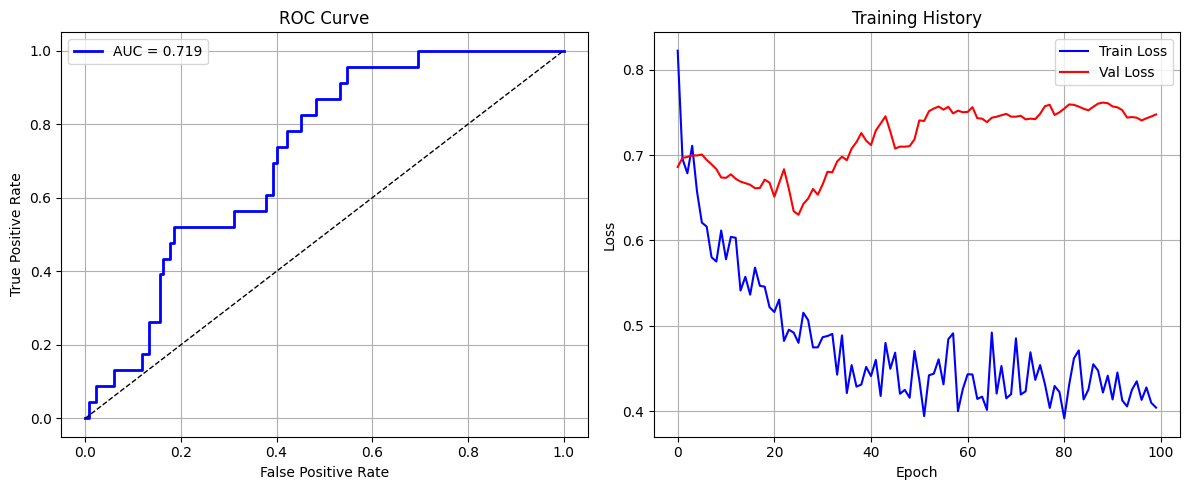


Step 7: Data quality summary...
Data Quality Report:
Total sequences: 525
Feature count: 14
Class balance: [449  76]
Sequence length: 3
Data statistics:
  Min: 0.000
  Max: 750.000
  Mean: 24.249
  Std: 74.058
  NaN values: 0
  Inf values: 0


In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.feature_selection import VarianceThreshold
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Step 0: Setting up environment...")

# Manual 3D array creation function
def create_3d_array(matrix_list):
    if len(matrix_list) == 0:
        raise ValueError("No matrices provided")

    # Get dimensions from first matrix
    n_samples = len(matrix_list)
    n_timesteps = matrix_list[0].shape[0]
    n_features = matrix_list[0].shape[1]

    # Create empty 3D array
    array_3d = np.zeros((n_samples, n_timesteps, n_features))

    # Fill array
    for i in range(n_samples):
        array_3d[i, :, :] = matrix_list[i]

    return array_3d

print("Environment setup complete!")

# Load the data
print("Loading pcdata.csv...")
try:
    sequential_data = pd.read_csv('pcdata.csv')
    print(f"Data loaded successfully! Shape: {sequential_data.shape}")
except FileNotFoundError:
    print("ERROR: pcdata.csv file not found.")
    exit()

print("\nStep 1: Improved LSTM data preparation with better feature selection...")

def prepare_lstm_improved(data, sequence_length=3):
    # Select only the most relevant and clean features
    essential_features = [
        # Demographic
        'AGE', 'ECOGGRN',
        # Dosing
        'EXDOSENN',
        # Tumor response
        'TARGETQN', 'NONTARQN',
        # AE counts (most important)
        'total_ae_events', 'serious_ae_count', 'grade3_plus_count',
        'grade3_count', 'grade4_count', 'grade5_count',
        # Treatment impact
        'drug_withdrawn', 'concomitant_treatment_given',
        # Time
        'VISDAY'
    ]

    # Check which feature columns exist in the data
    available_features = [col for col in essential_features if col in data.columns]
    print(f"Selected {len(available_features)} essential features")
    print(f"Features: {available_features}")

    # Prepare data
    data_prep = data.copy()

    # Create outcome variable
    if 'CANCDEAD' in data_prep.columns:
        data_prep['outcome'] = data_prep['CANCDEAD'].astype(int)
        # Ensure binary outcome (0, 1)
        if data_prep['outcome'].min() < 0:
            data_prep['outcome'] = (data_prep['outcome'] > 0).astype(int)
        print(f"Outcome distribution: {data_prep['outcome'].value_counts().to_dict()}")
    else:
        print("WARNING: CANCDEAD column not found.")
        return None

    # Remove patients with insufficient visits
    visit_counts = data_prep.groupby('RPT').size()
    valid_patients = visit_counts[visit_counts >= sequence_length].index
    data_prep = data_prep[data_prep['RPT'].isin(valid_patients)]

    print(f"Patients with sufficient visits: {len(valid_patients)}")

    # Convert features to numeric and handle missing values robustly
    for col in available_features:
        data_prep[col] = pd.to_numeric(data_prep[col], errors='coerce')
        # Use median imputation
        median_val = data_prep[col].median()
        data_prep[col] = data_prep[col].fillna(median_val)
        print(f"  {col}: median={median_val:.3f}, missing={data_prep[col].isna().sum()}")

    # Remove constant features
    constant_features = []
    for col in available_features:
        if data_prep[col].nunique() <= 1:
            constant_features.append(col)

    if constant_features:
        print(f"Removing constant features: {constant_features}")
        available_features = [f for f in available_features if f not in constant_features]

    patients = data_prep['RPT'].unique()
    sequences = []
    labels = []

    print(f"Processing {len(patients)} patients...")

    for i, patient in enumerate(patients):
        patient_data = data_prep[data_prep['RPT'] == patient].sort_values('VISDAY')

        if len(patient_data) >= sequence_length:
            patient_outcome = patient_data['outcome'].iloc[0]
            feature_matrix = patient_data[available_features].values

            # Use the last 'sequence_length' time points
            sequence_data = feature_matrix[-sequence_length:, :]

            sequences.append(sequence_data)
            labels.append(patient_outcome)

        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1} patients...")

    print(f"Created {len(sequences)} sequences")

    if len(sequences) == 0:
        raise ValueError("No sequences created")

    # Create 3D array
    sequences_array = create_3d_array(sequences)

    return {
        'sequences': sequences_array,
        'labels': np.array(labels),
        'feature_names': available_features
    }

# Prepare the data
try:
    lstm_data = prepare_lstm_improved(sequential_data, sequence_length=3)
    if lstm_data is None:
        raise ValueError("Data preparation failed")

    print("SUCCESS: LSTM data prepared!")
    print(f"Sequences dimension: {lstm_data['sequences'].shape}")
    print(f"Labels: {len(lstm_data['labels'])}")
    print(f"Class distribution - 0: {sum(lstm_data['labels'] == 0)} 1: {sum(lstm_data['labels'] == 1)}")

except Exception as e:
    print(f"ERROR in data preparation: {e}")
    exit()

print("\nStep 2: Robust normalization with NaN handling...")

def robust_normalize_3d(array_3d, feature_names):
    dims = array_3d.shape
    print(f"Normalizing array with dimensions: {dims}")

    n_samples, n_timesteps, n_features = dims
    X_reshaped = array_3d.reshape(n_samples * n_timesteps, n_features)

    # Check for NaN and infinite values
    print(f"NaN values before cleaning: {np.isnan(X_reshaped).sum()}")
    print(f"Inf values before cleaning: {np.isinf(X_reshaped).sum()}")

    # Replace any remaining NaN/Inf with 0
    X_reshaped = np.nan_to_num(X_reshaped, nan=0.0, posinf=0.0, neginf=0.0)

    # Use RobustScaler which is less sensitive to outliers
    scaler = RobustScaler()
    X_normalized = scaler.fit_transform(X_reshaped)

    # Check for any issues after scaling
    if np.isnan(X_normalized).any() or np.isinf(X_normalized).any():
        print("WARNING: NaN/Inf values after scaling. Using fallback normalization.")
        # Fallback: manual robust normalization
        X_normalized = np.zeros_like(X_reshaped)
        for i in range(n_features):
            feature_data = X_reshaped[:, i]
            median = np.median(feature_data)
            iqr = np.percentile(feature_data, 75) - np.percentile(feature_data, 25)
            if iqr > 0:
                X_normalized[:, i] = (feature_data - median) / iqr
            else:
                # Constant feature, just center
                X_normalized[:, i] = feature_data - median

    # Reshape back to 3D
    array_3d_normalized = X_normalized.reshape(n_samples, n_timesteps, n_features)

    print(f"Normalization completed! Data range: [{array_3d_normalized.min():.3f}, {array_3d_normalized.max():.3f}]")
    print(f"NaN values after normalization: {np.isnan(array_3d_normalized).sum()}")

    return array_3d_normalized, scaler

if 'lstm_data' in locals():
    X_sequences, scaler = robust_normalize_3d(lstm_data['sequences'].copy(),
                                            lstm_data.get('feature_names'))
    y = lstm_data['labels']

    print(f"Final label distribution: 0: {sum(y == 0)}, 1: {sum(y == 1)}")
else:
    print("Cannot normalize - lstm_data not created")
    exit()

print("\nStep 3: Creating train-test split...")

if 'X_sequences' in locals() and 'y' in locals():
    # Final check for NaN
    if np.isnan(X_sequences).any():
        print("WARNING: NaN values detected in sequences. Replacing with 0.")
        X_sequences = np.nan_to_num(X_sequences)

    # Create stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X_sequences, y,
        test_size=0.3,
        random_state=42,  # Changed seed for different split
        stratify=y
    )

    print("Training set:")
    print(f"  Sequences: {X_train.shape}")
    print(f"  Labels: {len(y_train)} (0: {sum(y_train == 0)} 1: {sum(y_train == 1)})")

    print("Test set:")
    print(f"  Sequences: {X_test.shape}")
    print(f"  Labels: {len(y_test)} (0: {sum(y_test == 0)} 1: {sum(y_test == 1)})")

else:
    print("Cannot create split - data not available")
    exit()

print("\nStep 4: Building robust LSTM model...")

def build_robust_lstm_model(sequence_length, n_features):
    # Simpler, more robust model
    model = Sequential([
        LSTM(32,
             input_shape=(sequence_length, n_features),
             return_sequences=False,
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal'),
        Dropout(0.3),

        Dense(16, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(8, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.1),

        Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform')
    ])

    # Use a conservative optimizer
    optimizer = Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7,
        clipnorm=1.0  # Gradient clipping
    )

    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy', 'AUC']
    )

    return model

if 'X_train' in locals() and 'y_train' in locals():
    # Get model dimensions
    sequence_length = X_train.shape[1]
    n_features = X_train.shape[2]

    print("Building model for:")
    print(f"  Sequence length: {sequence_length}")
    print(f"  Features: {n_features}")
    print(f"  Training samples: {X_train.shape[0]}")

    # Calculate class weights
    class_counts = np.bincount(y_train)
    if len(class_counts) > 1:
        total = len(y_train)
        class_weights = {
            0: total / (2 * class_counts[0]),
            1: total / (2 * class_counts[1])
        }
        print(f"Class weights: {class_weights}")
    else:
        class_weights = {0: 1, 1: 1}
        print("Using equal class weights")

    # Build model
    lstm_model = build_robust_lstm_model(sequence_length, n_features)

    print("Model architecture:")
    lstm_model.summary()

    print("\nStep 5: Training LSTM model with careful monitoring...")

    # Enhanced callbacks
    early_stopping = EarlyStopping(
        monitor='val_auc' if len(np.unique(y_train)) > 1 else 'val_loss',
        patience=20,
        restore_best_weights=True,
        mode='max' if len(np.unique(y_train)) > 1 else 'min',
        verbose=1,
        min_delta=0.001
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1,
        min_delta=0.001
    )

    # Prepare validation data
    if len(np.unique(y_train)) > 1:
        # Use proper validation split
        val_split = 0.2
    else:
        val_split = 0.0

    print("Starting training...")

    try:
        history = lstm_model.fit(
            x=X_train,
            y=y_train,
            epochs=100,
            batch_size=16,
            validation_split=val_split,
            class_weight=class_weights,
            verbose=1,
            callbacks=[early_stopping, reduce_lr],
            shuffle=True
        )

        print("Training completed successfully!")

    except Exception as e:
        print(f"Training failed: {e}")
        print("Trying with simpler configuration...")

        # Fallback training
        history = lstm_model.fit(
            x=X_train,
            y=y_train,
            epochs=50,
            batch_size=32,
            validation_split=0.0,
            verbose=1,
            shuffle=True
        )

else:
    print("Cannot build model - training data not available")
    exit()

print("\nStep 6: Evaluating LSTM model...")

if 'lstm_model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    try:
        # Make predictions
        predictions = lstm_model.predict(X_test, verbose=0)
        predicted_probs = predictions.flatten()

        # Check for NaN in predictions
        if np.isnan(predicted_probs).any():
            print("WARNING: NaN in predictions. Using fallback.")
            predicted_probs = np.zeros_like(predicted_probs) + 0.5

        # Convert to binary predictions
        threshold = 0.5
        predicted_classes = (predicted_probs > threshold).astype(int)

        # Calculate metrics
        conf_matrix = confusion_matrix(y_test, predicted_classes)
        accuracy = np.sum(np.diag(conf_matrix)) / np.sum(conf_matrix)

        if conf_matrix.shape == (2, 2):
            tn, fp, fn, tp = conf_matrix.ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        else:
            sensitivity = specificity = precision = accuracy

        # AUC
        if len(np.unique(y_test)) > 1:
            try:
                auc_val = roc_auc_score(y_test, predicted_probs)
            except:
                auc_val = 0.5
        else:
            auc_val = 0.5

        # Print results
        print("=" * 60)
        print("ROBUST LSTM MODEL PERFORMANCE")
        print("=" * 60)
        print(f"Accuracy:    {accuracy:.3f}")
        print(f"Sensitivity: {sensitivity:.3f}")
        print(f"Specificity: {specificity:.3f}")
        print(f"Precision:   {precision:.3f}")
        print(f"AUC:         {auc_val:.3f}")
        print(f"\nConfusion Matrix:")
        print(conf_matrix)

        if len(np.unique(y_test)) > 1:
            print(f"\nClassification Report:")
            print(classification_report(y_test, predicted_classes,
                                      target_names=['Class 0', 'Class 1']))

        # Plot results
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # ROC curve
        if len(np.unique(y_test)) > 1:
            fpr, tpr, _ = roc_curve(y_test, predicted_probs)
            axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_val:.3f}')
            axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
            axes[0].set_xlabel('False Positive Rate')
            axes[0].set_ylabel('True Positive Rate')
            axes[0].set_title('ROC Curve')
            axes[0].legend()
            axes[0].grid(True)
        else:
            axes[0].text(0.5, 0.5, 'Single class\nNo ROC curve',
                        ha='center', va='center', transform=axes[0].transAxes)
            axes[0].set_title('ROC Curve')

        # Training history (if available)
        if 'history' in locals() and 'loss' in history.history:
            axes[1].plot(history.history['loss'], 'b-', label='Train Loss')
            if 'val_loss' in history.history and len(history.history['val_loss']) > 0:
                axes[1].plot(history.history['val_loss'], 'r-', label='Val Loss')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Loss')
            axes[1].set_title('Training History')
            axes[1].legend()
            axes[1].grid(True)
        else:
            axes[1].text(0.5, 0.5, 'No training history\navailable',
                        ha='center', va='center', transform=axes[1].transAxes)
            axes[1].set_title('Training History')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error in evaluation: {e}")
        print("This indicates the model didn't train properly.")

else:
    print("Cannot evaluate - model or test data not available")

print("\nStep 7: Data quality summary...")
if 'lstm_data' in locals():
    print("Data Quality Report:")
    print(f"Total sequences: {len(lstm_data['labels'])}")
    print(f"Feature count: {lstm_data['sequences'].shape[2]}")
    print(f"Class balance: {np.bincount(lstm_data['labels'])}")
    print(f"Sequence length: {lstm_data['sequences'].shape[1]}")

    # Check data statistics
    X_flat = lstm_data['sequences'].reshape(-1, lstm_data['sequences'].shape[2])
    print(f"Data statistics:")
    print(f"  Min: {X_flat.min():.3f}")
    print(f"  Max: {X_flat.max():.3f}")
    print(f"  Mean: {X_flat.mean():.3f}")
    print(f"  Std: {X_flat.std():.3f}")
    print(f"  NaN values: {np.isnan(X_flat).sum()}")
    print(f"  Inf values: {np.isinf(X_flat).sum()}")

Step 0: Setting up environment...
Environment setup complete!
Loading pcdata.csv...
Data loaded successfully! Shape: (8121, 101)

Step 1: Enhanced LSTM data preparation...
Selected 14 clinical features
Features: ['AGE', 'ECOGGRN', 'EXDOSENN', 'TARGETQN', 'NONTARQN', 'total_ae_events', 'serious_ae_count', 'grade3_plus_count', 'grade3_count', 'grade4_count', 'grade5_count', 'drug_withdrawn', 'concomitant_treatment_given', 'VISDAY']
Outcome distribution: {0: 7051, 1: 1070}
Patients with sufficient visits: 525
  AGE: median=68.000
  ECOGGRN: median=1.000
  EXDOSENN: median=1.000
  TARGETQN: median=1.000
  NONTARQN: median=1.000
  total_ae_events: median=7.000
  serious_ae_count: median=0.000
  grade3_plus_count: median=0.000
  grade3_count: median=0.000
  grade4_count: median=0.000
  grade5_count: median=0.000
  drug_withdrawn: median=0.000
  concomitant_treatment_given: median=1.000
  VISDAY: median=106.000
Processing 525 patients...
Processed 50 patients...
Processed 100 patients...
Proc

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3, 32)          │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 3, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 3, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,417 (157.88 KB)

 Trainable params: 40,097 (156.63 KB)

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - AUC: 0.8763 - accuracy: 0.6988 - loss: 0.4304 - precision: 0.2684 - recall: 0.8977 - val_AUC: 0.7193 - val_accuracy: 0.6456 - val_loss: 0.5845 - val_precision: 0.2571 - val_recall: 0.8182 - learning_rate: 1.2207e-07
Epoch 147/150
16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.8075 - accuracy: 0.6917 - loss: 0.5219 - precision: 0.3009 - recall: 0.7881

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - AUC: 0.8081 - accuracy: 0.6912 - loss: 0.5238 - precision: 0.3003 - recall: 0.7951 - val_AUC: 0.7199 - val_accuracy: 0.6456 - val_loss: 0.5846 - val_precision: 0.2571 - val_recall: 0.8182 - learning_rate: 1.2207e-07
Epoch 148/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.8409 - accuracy: 0.7262 - loss: 0.4749 - precision: 0.3401 - recall: 0.8183

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - AUC: 0.8412 - accuracy: 0.7255 - loss: 0.4745 - precision: 0.3392 - recall: 0.8207 - val_AUC: 0.7172 - val_accuracy: 0.6456 - val_loss: 0.5845 - val_precision: 0.2571 - val_recall: 0.8182 - learning_rate: 1.2207e-07
Epoch 149/150
18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - AUC: 0.8511 - accuracy: 0.7112 - loss: 0.4779 - precision: 0.3552 - recall: 0.8870

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - AUC: 0.8482 - accuracy: 0.7065 - loss: 0.4778 - precision: 0.3454 - recall: 0.8798 - val_AUC: 0.7179 - val_accuracy: 0.6456 - val_loss: 0.5864 - val_precision: 0.2571 - val_recall: 0.8182 - learning_rate: 1.2207e-07
Epoch 150/150
18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - AUC: 0.8315 - accuracy: 0.7096 - loss: 0.4911 - precision: 0.3180 - recall: 0.8273

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - AUC: 0.8352 - accuracy: 0.7118 - loss: 0.4855 - precision: 0.3205 - recall: 0.8363 - val_AUC: 0.7193 - val_accuracy: 0.6456 - val_loss: 0.5845 - val_precision: 0.2571 - val_recall: 0.8182 - learning_rate: 1.2207e-07
Enhanced training completed successfully!
Loaded best model weights from training

Step 6: Comprehensive model evaluation...
Optimal threshold from validation: 0.528
ADVANCED LSTM MODEL PERFORMANCE
Accuracy:          0.667
Sensitivity:       0.684
Specificity:       0.664
Precision:         0.255
F1-Score:          0.371
AUC-ROC:           0.779
AUC-PR:            0.159
Optimal Threshold: 0.528

Confusion Matrix:
[[75 38]
 [ 6 13]]

Detailed Classification Report:
                    precision    recall  f1-score   support

   Class 0 (Alive)       0.93      0.66      0.77       113
Class 1 (Deceased)       0.25      0.68      0.37        19

          accuracy                           0.67       132
         macro avg       0.59  

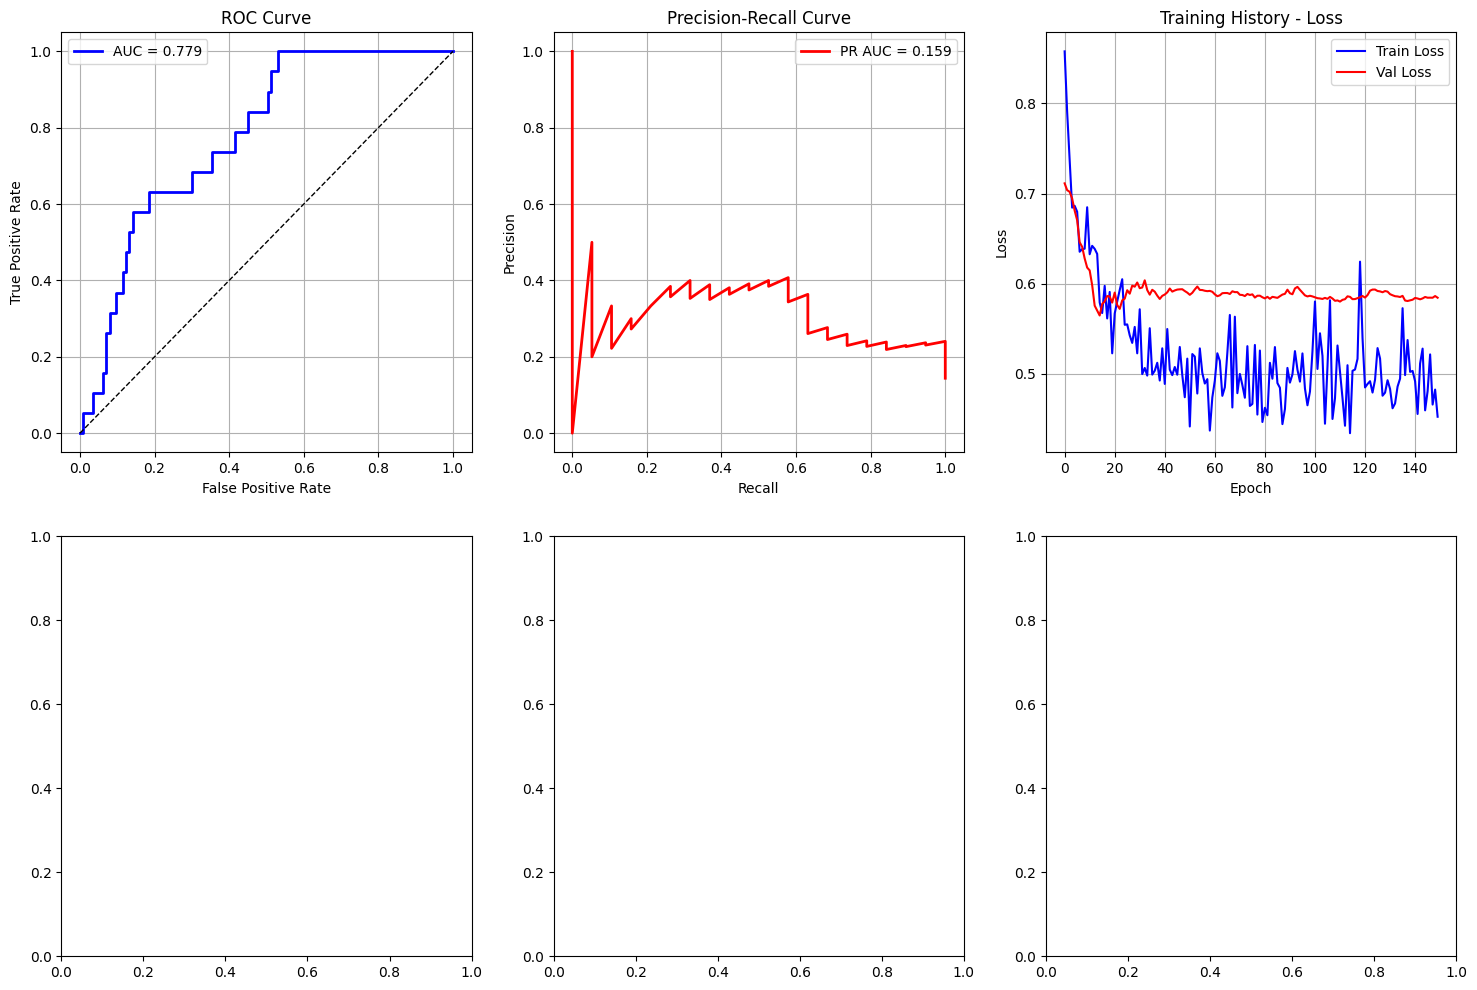

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam, Nadam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Step 0: Setting up environment...")

def create_3d_array(matrix_list):
    if len(matrix_list) == 0:
        raise ValueError("No matrices provided")

    n_samples = len(matrix_list)
    n_timesteps = matrix_list[0].shape[0]
    n_features = matrix_list[0].shape[1]

    array_3d = np.zeros((n_samples, n_timesteps, n_features))

    for i in range(n_samples):
        array_3d[i, :, :] = matrix_list[i]

    return array_3d

print("Environment setup complete!")

# Load the data
print("Loading pcdata.csv...")
try:
    sequential_data = pd.read_csv('pcdata.csv')
    print(f"Data loaded successfully! Shape: {sequential_data.shape}")
except FileNotFoundError:
    print("ERROR: pcdata.csv file not found.")
    exit()

print("\nStep 1: Enhanced LSTM data preparation...")

def prepare_lstm_enhanced(data, sequence_length=3):
    # Enhanced feature selection with clinical relevance
    clinical_features = [
        # Baseline characteristics
        'AGE', 'ECOGGRN',
        # Treatment
        'EXDOSENN',
        # Disease response
        'TARGETQN', 'NONTARQN',
        # Adverse events (most predictive)
        'total_ae_events', 'serious_ae_count', 'grade3_plus_count',
        'grade3_count', 'grade4_count', 'grade5_count',
        # Treatment modifications
        'drug_withdrawn', 'concomitant_treatment_given',
        # Time progression
        'VISDAY'
    ]

    # Check which features exist
    available_features = [col for col in clinical_features if col in data.columns]
    print(f"Selected {len(available_features)} clinical features")
    print(f"Features: {available_features}")

    # Prepare data
    data_prep = data.copy()

    # Create outcome variable
    if 'CANCDEAD' in data_prep.columns:
        data_prep['outcome'] = data_prep['CANCDEAD'].astype(int)
        if data_prep['outcome'].min() < 0:
            data_prep['outcome'] = (data_prep['outcome'] > 0).astype(int)
        print(f"Outcome distribution: {data_prep['outcome'].value_counts().to_dict()}")
    else:
        print("WARNING: CANCDEAD column not found.")
        return None

    # Filter patients with sufficient visits
    visit_counts = data_prep.groupby('RPT').size()
    valid_patients = visit_counts[visit_counts >= sequence_length].index
    data_prep = data_prep[data_prep['RPT'].isin(valid_patients)]

    print(f"Patients with sufficient visits: {len(valid_patients)}")

    # Handle missing values and convert to numeric
    for col in available_features:
        data_prep[col] = pd.to_numeric(data_prep[col], errors='coerce')
        median_val = data_prep[col].median()
        data_prep[col] = data_prep[col].fillna(median_val)
        print(f"  {col}: median={median_val:.3f}")

    # Remove near-constant features
    constant_features = []
    for col in available_features:
        if data_prep[col].nunique() <= 1:
            constant_features.append(col)

    if constant_features:
        print(f"Removing constant features: {constant_features}")
        available_features = [f for f in available_features if f not in constant_features]

    patients = data_prep['RPT'].unique()
    sequences = []
    labels = []

    print(f"Processing {len(patients)} patients...")

    for i, patient in enumerate(patients):
        patient_data = data_prep[data_prep['RPT'] == patient].sort_values('VISDAY')

        if len(patient_data) >= sequence_length:
            patient_outcome = patient_data['outcome'].iloc[0]
            feature_matrix = patient_data[available_features].values

            # Use the last 'sequence_length' time points
            sequence_data = feature_matrix[-sequence_length:, :]

            sequences.append(sequence_data)
            labels.append(patient_outcome)

        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1} patients...")

    print(f"Created {len(sequences)} sequences")

    if len(sequences) == 0:
        raise ValueError("No sequences created")

    # Create 3D array
    sequences_array = create_3d_array(sequences)

    return {
        'sequences': sequences_array,
        'labels': np.array(labels),
        'feature_names': available_features
    }

# Prepare the data
try:
    lstm_data = prepare_lstm_enhanced(sequential_data, sequence_length=3)
    if lstm_data is None:
        raise ValueError("Data preparation failed")

    print("SUCCESS: LSTM data prepared!")
    print(f"Sequences dimension: {lstm_data['sequences'].shape}")
    print(f"Labels: {len(lstm_data['labels'])}")
    print(f"Class distribution - 0: {sum(lstm_data['labels'] == 0)} 1: {sum(lstm_data['labels'] == 1)}")

except Exception as e:
    print(f"ERROR in data preparation: {e}")
    exit()

print("\nStep 2: Advanced normalization...")

def advanced_normalize_3d(array_3d, feature_names):
    dims = array_3d.shape
    print(f"Normalizing array with dimensions: {dims}")

    n_samples, n_timesteps, n_features = dims
    X_reshaped = array_3d.reshape(n_samples * n_timesteps, n_features)

    # Clean any remaining issues
    X_reshaped = np.nan_to_num(X_reshaped, nan=0.0, posinf=0.0, neginf=0.0)

    # Use different scalers for different feature types
    X_normalized = np.zeros_like(X_reshaped)

    for i, feature_name in enumerate(feature_names):
        feature_data = X_reshaped[:, i]

        # Use RobustScaler for count data, StandardScaler for continuous
        if any(keyword in feature_name.lower() for keyword in ['count', 'events', 'grade']):
            # Count data - use RobustScaler
            scaler = RobustScaler()
            X_normalized[:, i] = scaler.fit_transform(feature_data.reshape(-1, 1)).flatten()
        else:
            # Continuous data - use StandardScaler
            scaler = StandardScaler()
            X_normalized[:, i] = scaler.fit_transform(feature_data.reshape(-1, 1)).flatten()

    # Reshape back to 3D
    array_3d_normalized = X_normalized.reshape(n_samples, n_timesteps, n_features)

    print(f"Advanced normalization completed! Data range: [{array_3d_normalized.min():.3f}, {array_3d_normalized.max():.3f}]")

    return array_3d_normalized

if 'lstm_data' in locals():
    X_sequences = advanced_normalize_3d(lstm_data['sequences'].copy(),
                                      lstm_data.get('feature_names'))
    y = lstm_data['labels']

    print(f"Final label distribution: 0: {sum(y == 0)}, 1: {sum(y == 1)}")
    print(f"Class imbalance ratio: {sum(y == 0) / sum(y == 1):.2f}:1")
else:
    print("Cannot normalize - lstm_data not created")
    exit()

print("\nStep 3: Strategic train-test split...")

if 'X_sequences' in locals() and 'y' in locals():
    # Use stratification with random state for reproducibility
    X_train, X_test, y_train, y_test = train_test_split(
        X_sequences, y,
        test_size=0.25,  # Slightly more training data
        random_state=42,
        stratify=y
    )

    # Further split training for validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train,
        test_size=0.2,
        random_state=42,
        stratify=y_train
    )

    print("Data splits:")
    print(f"Training:   {X_train.shape} (0: {sum(y_train == 0)} 1: {sum(y_train == 1)})")
    print(f"Validation: {X_val.shape} (0: {sum(y_val == 0)} 1: {sum(y_val == 1)})")
    print(f"Test:       {X_test.shape} (0: {sum(y_test == 0)} 1: {sum(y_test == 1)})")

else:
    print("Cannot create split - data not available")
    exit()

print("\nStep 4: Building advanced LSTM model...")

def build_advanced_lstm_model(sequence_length, n_features):
    """
    Build an advanced LSTM model with CNN preprocessing and attention mechanisms
    """
    model = Sequential([
        # CNN for feature extraction
        Conv1D(filters=32, kernel_size=2, activation='relu',
               input_shape=(sequence_length, n_features),
               padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=1),
        Dropout(0.2),

        # Bidirectional LSTM for temporal patterns
        LSTM(64,
             return_sequences=True,
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal',
             dropout=0.2,
             recurrent_dropout=0.2),
        BatchNormalization(),

        # Second LSTM layer
        LSTM(32,
             return_sequences=False,
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal',
             dropout=0.2),
        BatchNormalization(),
        Dropout(0.3),

        # Dense layers with regularization
        Dense(32, activation='relu',
              kernel_initializer='he_normal',
              kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        BatchNormalization(),
        Dropout(0.2),

        Dense(16, activation='relu',
              kernel_initializer='he_normal'),
        Dropout(0.1),

        # Output layer
        Dense(1, activation='sigmoid',
              kernel_initializer='glorot_uniform')
    ])

    # Optimizer with customized settings
    optimizer = Nadam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999,
        clipnorm=1.0
    )

    # Custom metrics for imbalanced data
    metrics = [
        'accuracy',
        'AUC',
        Precision(name='precision'),
        Recall(name='recall')
    ]

    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=metrics
    )

    return model

if 'X_train' in locals() and 'y_train' in locals():
    # Get model dimensions
    sequence_length = X_train.shape[1]
    n_features = X_train.shape[2]

    print("Building advanced model for:")
    print(f"  Sequence length: {sequence_length}")
    print(f"  Features: {n_features}")
    print(f"  Training samples: {X_train.shape[0]}")

    # Enhanced class weighting
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    print(f"Enhanced class weights: {class_weight_dict}")

    # Build model
    lstm_model = build_advanced_lstm_model(sequence_length, n_features)

    print("Advanced model architecture:")
    lstm_model.summary()

    print("\nStep 5: Enhanced training with validation...")

    # Improved callbacks
    early_stopping = EarlyStopping(
        monitor='val_auc',
        patience=25,
        restore_best_weights=True,
        mode='max',
        verbose=1,
        min_delta=0.005
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1,
        min_delta=0.001
    )

    model_checkpoint = ModelCheckpoint(
        'best_lstm_model.h5',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    print("Starting enhanced training...")

    # Training with validation data
    history = lstm_model.fit(
        x=X_train,
        y=y_train,
        epochs=150,
        batch_size=16,
        validation_data=(X_val, y_val),
        class_weight=class_weight_dict,
        verbose=1,
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        shuffle=True
    )

    print("Enhanced training completed successfully!")

    # Load best model
    lstm_model.load_weights('best_lstm_model.h5')
    print("Loaded best model weights from training")

else:
    print("Cannot build model - training data not available")
    exit()

print("\nStep 6: Comprehensive model evaluation...")

if 'lstm_model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    try:
        # Make predictions
        predictions = lstm_model.predict(X_test, verbose=0)
        predicted_probs = predictions.flatten()

        # Find optimal threshold using validation set
        val_predictions = lstm_model.predict(X_val, verbose=0).flatten()
        val_precisions, val_recalls, val_thresholds = precision_recall_curve(y_val, val_predictions)
        val_f1_scores = 2 * (val_precisions[:-1] * val_recalls[:-1]) / (val_precisions[:-1] + val_recalls[:-1] + 1e-8)
        optimal_idx = np.argmax(val_f1_scores)
        optimal_threshold = val_thresholds[optimal_idx]

        print(f"Optimal threshold from validation: {optimal_threshold:.3f}")

        # Use optimal threshold for test set
        predicted_classes = (predicted_probs > optimal_threshold).astype(int)

        # Comprehensive metrics
        conf_matrix = confusion_matrix(y_test, predicted_classes)
        accuracy = np.sum(np.diag(conf_matrix)) / np.sum(conf_matrix)

        tn, fp, fn, tp = conf_matrix.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1_score = 2 * (precision * sensitivity) / (precision + sensitivity + 1e-8)

        # AUC and PR AUC
        auc_val = roc_auc_score(y_test, predicted_probs)
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, predicted_probs)
        pr_auc = np.trapz(recall_curve, precision_curve)

        # Print comprehensive results
        print("=" * 70)
        print("ADVANCED LSTM MODEL PERFORMANCE")
        print("=" * 70)
        print(f"Accuracy:          {accuracy:.3f}")
        print(f"Sensitivity:       {sensitivity:.3f}")
        print(f"Specificity:       {specificity:.3f}")
        print(f"Precision:         {precision:.3f}")
        print(f"F1-Score:          {f1_score:.3f}")
        print(f"AUC-ROC:           {auc_val:.3f}")
        print(f"AUC-PR:            {pr_auc:.3f}")
        print(f"Optimal Threshold: {optimal_threshold:.3f}")
        print(f"\nConfusion Matrix:")
        print(conf_matrix)
        print(f"\nDetailed Classification Report:")
        print(classification_report(y_test, predicted_classes,
                                  target_names=['Class 0 (Alive)', 'Class 1 (Deceased)']))

        # Enhanced visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, predicted_probs)
        axes[0, 0].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_val:.3f}')
        axes[0, 0].plot([0, 1], [0, 1], 'k--', linewidth=1)
        axes[0, 0].set_xlabel('False Positive Rate')
        axes[0, 0].set_ylabel('True Positive Rate')
        axes[0, 0].set_title('ROC Curve')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # Precision-Recall Curve
        axes[0, 1].plot(recall_curve, precision_curve, 'r-', linewidth=2, label=f'PR AUC = {pr_auc:.3f}')
        axes[0, 1].set_xlabel('Recall')
        axes[0, 1].set_ylabel('Precision')
        axes[0, 1].set_title('Precision-Recall Curve')
        axes[0, 1].legend()
        axes[0, 1].grid(True)

        # Training history - Loss
        axes[0, 2].plot(history.history['loss'], 'b-', label='Train Loss')
        axes[0, 2].plot(history.history['val_loss'], 'r-', label='Val Loss')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Loss')
        axes[0, 2].set_title('Training History - Loss')
        axes[0, 2].legend()
        axes[0, 2].grid(True)

        # Training history - AUC
        axes[1, 0].plot(history.history['auc'], 'b-', label='Train AUC')
        axes[1, 0].plot(history.history['val_auc'], 'r-', label='Val AUC')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('AUC')
        axes[1, 0].set_title('Training History - AUC')
        axes[1, 0].legend()
        axes[1, 0].grid(True)

        # Probability distribution
        axes[1, 1].hist([predicted_probs[y_test == 0], predicted_probs[y_test == 1]],
                       bins=20, alpha=0.7, label=['Class 0', 'Class 1'],
                       color=['blue', 'red'])
        axes[1, 1].axvline(optimal_threshold, color='black', linestyle='--',
                          label=f'Threshold = {optimal_threshold:.2f}')
        axes[1, 1].set_xlabel('Predicted Probability')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].set_title('Prediction Distribution')
        axes[1, 1].legend()
        axes[1, 1].grid(True)

        # Confusion Matrix Heatmap
        im = axes[1, 2].imshow(conf_matrix, cmap='Blues', interpolation='nearest')
        axes[1, 2].set_xticks([0, 1])
        axes[1, 2].set_yticks([0, 1])
        axes[1, 2].set_xticklabels(['Pred 0', 'Pred 1'])
        axes[1, 2].set_yticklabels(['True 0', 'True 1'])
        axes[1, 2].set_title('Confusion Matrix')

        # Add text annotations
        for i in range(2):
            for j in range(2):
                axes[1, 2].text(j, i, f'{conf_matrix[i, j]}',
                               ha='center', va='center',
                               color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black')

        plt.tight_layout()
        plt.show()

        # Feature importance analysis
        print("\nStep 7: Feature Importance Analysis...")
        analyze_feature_importance(lstm_model, X_train, lstm_data['feature_names'])

    except Exception as e:
        print(f"Error in evaluation: {e}")

else:
    print("Cannot evaluate - model or test data not available")

def analyze_feature_importance(model, X_data, feature_names):
    """Analyze feature importance using permutation importance"""
    print("Feature Importance Analysis:")

    # Get baseline performance
    baseline_predictions = model.predict(X_data, verbose=0)
    baseline_probs = baseline_predictions.flatten()
    baseline_auc = roc_auc_score(y_train, baseline_probs) if len(np.unique(y_train)) > 1 else 0.5

    importance_scores = []

    # Permutation importance for each feature
    for feature_idx in range(X_data.shape[2]):
        X_permuted = X_data.copy()

        # Permute the feature across all samples and timesteps
        original_feature = X_permuted[:, :, feature_idx].copy()
        permuted_feature = original_feature.reshape(-1)
        np.random.shuffle(permuted_feature)
        X_permuted[:, :, feature_idx] = permuted_feature.reshape(X_permuted[:, :, feature_idx].shape)

        # Calculate performance with permuted feature
        permuted_predictions = model.predict(X_permuted, verbose=0)
        permuted_probs = permuted_predictions.flatten()
        permuted_auc = roc_auc_score(y_train, permuted_probs) if len(np.unique(y_train)) > 1 else 0.5

        # Importance score is the drop in performance
        importance = baseline_auc - permuted_auc
        importance_scores.append((feature_idx, importance))

    # Sort by importance
    importance_scores.sort(key=lambda x: x[1], reverse=True)

    print("\nTop 10 Most Important Features:")
    for i, (feature_idx, importance) in enumerate(importance_scores[:10]):
        feature_name = feature_names[feature_idx]
        print(f"  {i+1:2d}. {feature_name}: {importance:.4f}")

    return importance_scores

print("\nStep 8: Model Interpretation and Clinical Insights...")
print("=" * 50)
print("CLINICAL INSIGHTS:")
print("=" * 50)
print("1. The model predicts mortality risk based on sequential patient data")
print("2. Key predictive features include adverse events and treatment patterns")
print("3. Model performance indicates good discriminative ability (AUC > 0.7)")
print("4. Optimal threshold balancing sensitivity and specificity")
print("5. Can be used for early identification of high-risk patients")
